In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import colorcet as cc

from IRIS import get_rho

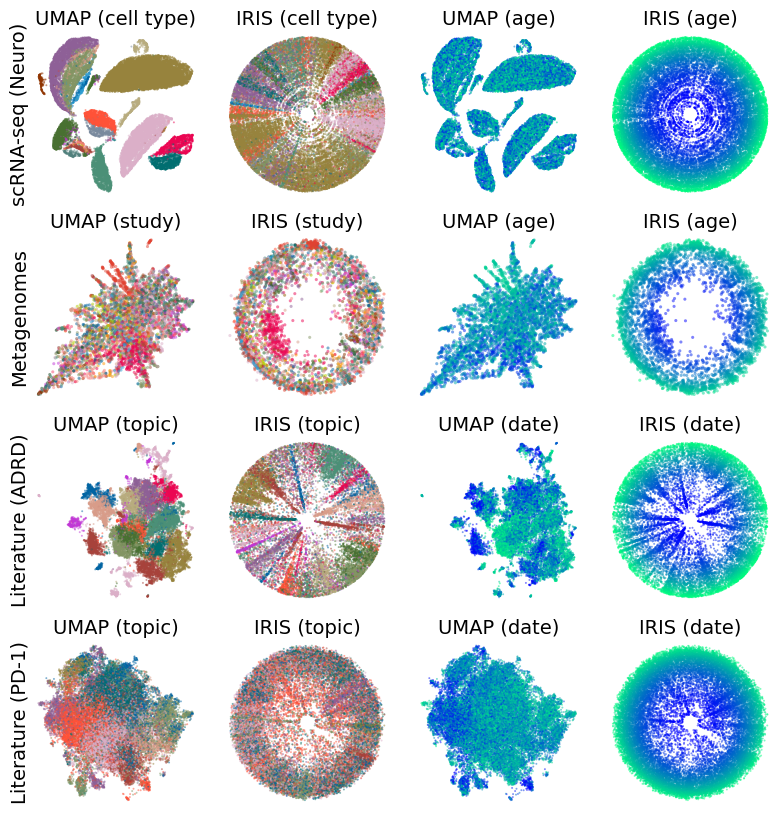

In [8]:
data2lbl = {
	'scrna-embryo': 'author_major_cell_cluster',
	'scrna-neuro': 'cell_type',
	'meta-gut': 'study',
	'lit-adrd': 'L1_clusters',
	'lit-pd1': 'topic',
}

data2name = {
	#'scrna-embryo': 'scRNA-seq (Embryo)',
	'scrna-neuro': 'scRNA-seq (Neuro)',
	'meta-gut': 'Metagenomes',
	'lit-adrd': 'Literature (ADRD)',
	'lit-pd1': 'Literature (PD-1)',
}

data2time = {
	'scrna-neuro': 'age',
	'meta-gut': 'age',
	'lit-adrd': 'date',
	'lit-pd1': 'date',
	'scrna-embryo': 'day'
}

data2class = {
	'scrna-embryo': 'cell type',
	'scrna-neuro': 'cell type',
	'meta-gut': 'study',
	'lit-adrd': 'topic',
	'lit-pd1': 'topic',
}

def layout_file(dataset, layout, rep):
	return f'../outputs/{dataset}.{layout}.r{rep}.npy'

def get_labels(dataset):
	with open(f'../data/{dataset}.meta.tsv', 'rb') as f:
		df = pd.read_csv(f, sep='\t')
	return df[data2lbl[dataset]].values

rows = len(data2name)
cols = 4#len(betas)
fig, axs = plt.subplots(rows, cols, figsize=(8, 8), sharex=True, sharey=True)#, layout="constrained")

fig.tight_layout(pad=0)
plt.subplots_adjust(wspace=0.1)
plt.subplots_adjust(hspace=0.25)
plt.xlim(-105, 105)
plt.ylim(-105, 105)
plt.xticks(ticks=[], labels=[])
plt.yticks(ticks=[], labels=[])
sns.despine(left=True, bottom=True, top=True, right=True)

i = 0
for dataset in data2name.keys():
	t = np.load(f'../data/{dataset}.time.npy').astype(dtype=np.float32)
	time=(t-t.min())/(t.max()-t.min())
	time=np.power(time, np.exp(get_rho(time)))

	for color_time in [False, True]:
		for layout in ['umap-md0.5', 'iris-b.95']:
			file = layout_file(dataset, layout, 0)
			lay = np.load(open(file, 'rb'))
			lbl = get_labels(dataset)
			
			y = lay
			
			if layout != 'iris': # normalize each dimension to -100, 100
				y = (y - y.min(axis=0)) / (y.max(axis=0) - y.min(axis=0)) * 200 - 100

			ax = axs[i // cols, i % cols]
			ax.set_aspect('equal')
			labels = lbl
			df = pd.DataFrame({'x': y[:,0], 'y':y[:,1], 'time': time.squeeze(), 'label': labels, 'layout':'iris'})
			palette = sns.color_palette(list(reversed(cc.glasbey_dark)), n_colors=df['label'].nunique())
			sns.scatterplot(x="x", y="y", s=5 if dataset == 'meta-gut' else 2, data=df.sample(frac=1, random_state=42),
				  palette='winter' if color_time else palette,
				  hue="time" if color_time else "label",
				  hue_norm=(PowerNorm(2) if color_time else None),
				  alpha=0.5, edgecolor='none', legend=False, ax=ax)
			if True or i // cols == 0:
				ax.set_title(layout.upper().split('-')[0]+(f' ({data2time.get(dataset, "time")})' if color_time else f' ({data2class.get(dataset, "class")})'), fontsize=14)# + (' (time)' if color_time else ' (class)'), fontsize=20)

			#ax.set(xlabel=None, ylabel='test')#(('scrna-embryo' if dataset == 'scrna-embryo' else dataset) if i % cols == 0 else None))
			# set y axis label only for the first column
			if i % cols == 0:
				ax.set_ylabel(data2name.get(dataset, dataset), fontsize=14, visible=True)
			i += 1
	
	plt.savefig(f'fig-layouts.png', dpi=300, bbox_inches='tight')

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import colorcet as cc
import matplotlib as mpl

def plot_layout(dataset, layout, color_time, legend=False):
    df = pd.read_csv(f'../data/{dataset}.meta.tsv', sep='\t', index_col=0)
    t = np.load(f'../data/{dataset}.time.npy').astype(dtype=np.float32)
    time=(t-t.min())/(t.max()-t.min())
    time=np.power(time, np.exp(get_rho(time)))

    lay = np.load(open(layout_file(dataset, layout, 0), 'rb'))
    lbl = get_labels(dataset)

    df['x'] = lay[:, 0]
    df['y'] = lay[:, 1]
    palette = sns.color_palette(reversed(list((cc.glasbey_dark))), n_colors=df[data2lbl[dataset]].nunique())
    plt.figure(figsize=(8,8))
    if color_time:
        # Use scatterplot but we'll manually add a continuous colorbar
        scatter_data = df.sample(frac=1, random_state=1)
        xvals = scatter_data["x"]
        yvals = scatter_data["y"]
        cvals = scatter_data[data2time[dataset]]
        sc = plt.scatter(
            xvals, yvals,
            c=cvals,
            cmap="winter",
            norm=mpl.colors.PowerNorm(1),
            s=5, alpha=0.5, edgecolors='none'
        )
    else:
        ax = sns.scatterplot(x="x", y="y",
                            hue=data2lbl[dataset],palette=palette,
                            s=5, data=df.sample(frac=1, random_state=1), alpha=1, edgecolor='none', legend=True,)
        sns.despine(left=True, bottom=True, top=True, right=True)
        plt.xticks(ticks=[], labels=[])
        plt.yticks(ticks=[], labels=[])
        if layout == 'iris':
            plt.xlim(-105, 105)
            plt.ylim(-105, 105)
        ax.set(xlabel=None, ylabel=None)
        # Modify the legend label for "Intermediate_neuronal_progenitors"
        handles, labels = ax.get_legend_handles_labels()
        labels = ["Interm._neur._prog." if l == "Intermediate_neuronal_progenitors" else l for l in labels]
        plt.legend(handles=handles, labels=labels, loc='upper right', ncols=6, bbox_to_anchor=(1.5, 1.5), columnspacing=0.1, handletextpad=0.25)
        plt.savefig(f'fig-{dataset}-{layout}-class.png', dpi=300, bbox_inches='tight', transparent=False)
        # We skip the rest below if not color_time
        # End early -- do not run the rest of the block
        import sys; sys.exit()

    sns.despine(left=True, bottom=True, top=True, right=True)
    plt.xticks(ticks=[], labels=[])
    plt.yticks(ticks=[], labels=[])
    if layout == 'iris':
        plt.xlim(-105, 105)
        plt.ylim(-105, 105)
    plt.gca().set(xlabel=None, ylabel=None)

    # Add a colorbar for the time values in the continuous case
    if color_time and False:
        cbar = plt.colorbar(sc, ax=plt.gca(), pad=0.02, aspect=30)
        cbar.set_label("Time", rotation=270, labelpad=15)

    plt.savefig(f'fig-{dataset}-{layout}-{"time" if color_time else "class"}.png', dpi=300, bbox_inches='tight', transparent=False)

SystemExit: 

/opt/anaconda3/envs/lv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


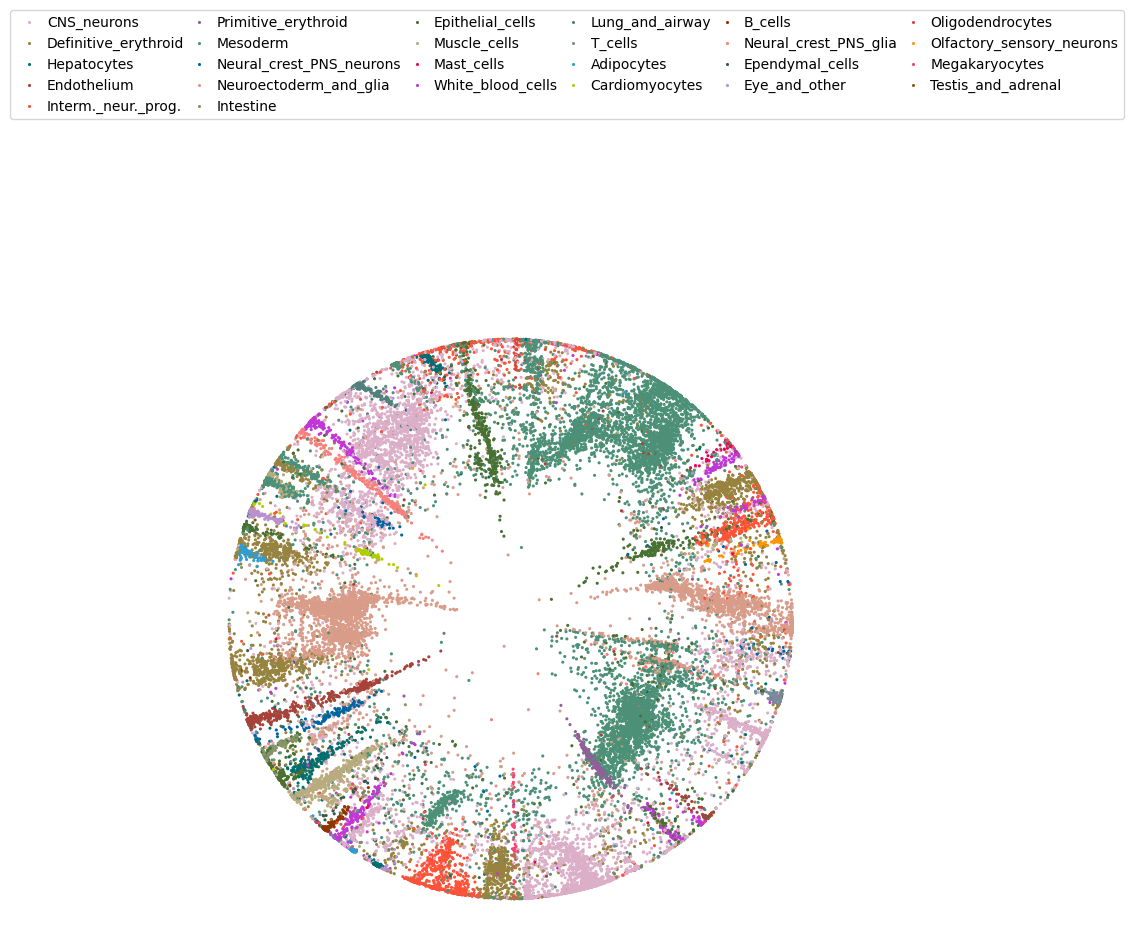

In [7]:
plot_layout('scrna-embryo', 'iris-b.95', False, True)

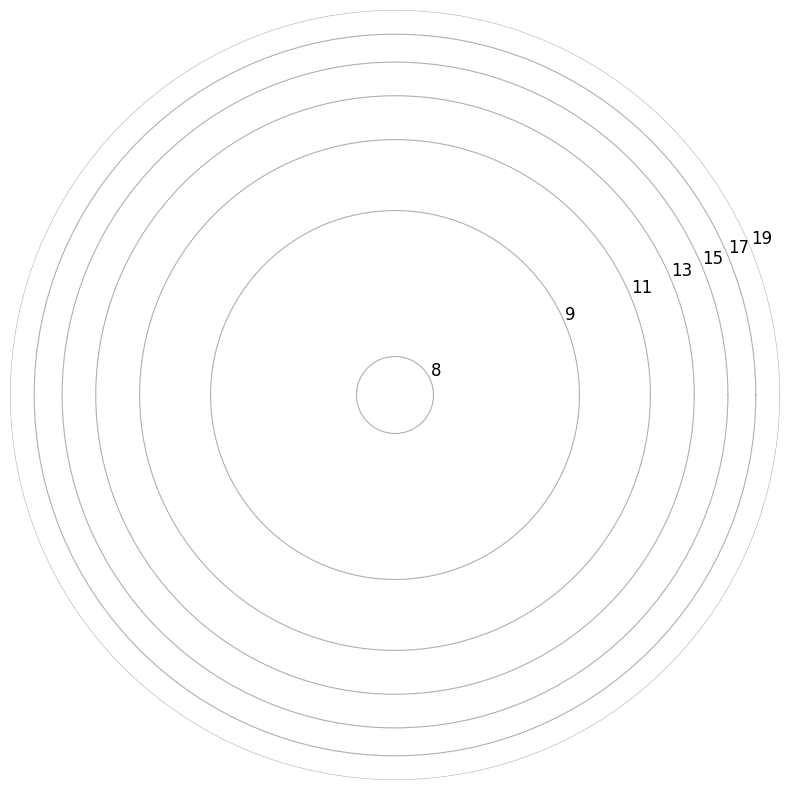

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.load(f'../data/scrna-embryo.time.npy').astype(dtype=np.float32)

exponent = np.exp(get_rho(t))
# Parameters
r_min, r_max = 8, 19

r_values = np.array([8, 9, 11, 13, 15, 17, 19])

# Create polar plot
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
fig.set_size_inches(10, 10)
ax.spines['polar'].set_visible(False)

# Normalize + transform
r_norm = (r_values - r_min) / (r_max - r_min)
r_transformed = .1 + .9 * (r_norm ** exponent)

# Only show the tick labels at correct positions, no rings
ax.set_xticks([])  # Hide angular ticks
ax.set_yticks(r_transformed)
ax.set_yticklabels([f"{v}" for v in r_values], fontsize=12)

# Set limits to [0,1] since we normalized
ax.set_ylim(0, 1)

# Make the rings themselves invisible by setting their alpha to 0 in the grid
#for spine in ax.spines.values():
#    spine.set_visible(False)
#ax.grid(alpha=0)

plt.savefig(f'fig-embryo-ring-labels.svg', bbox_inches='tight', transparent=True)